In [7]:
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import StandardScaler

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,BatchNormalization, Dense,Dropout,Flatten


In [9]:
#LOAD DATA
(X_train,y_train),(X_test,y_test)= mnist.load_data()
(X_train,y_train)=(X_train[:5000],y_train[:5000])
(X_test,y_test)=(X_test[:1000],y_test[:1000])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
#PREPROCESS image - Reshape + Normalize
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0


In [11]:
#BUILD MODEL
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
#COMPILE MODEL
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#TRAIN MODEL
history=model.fit(X_train,y_train,
                  validation_data=(X_test,y_test),
                  epochs=5,batch_size=32,verbose=1)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8138 - loss: 0.6191 - val_accuracy: 0.4620 - val_loss: 1.6194
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9354 - loss: 0.2126 - val_accuracy: 0.6880 - val_loss: 0.9146
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9616 - loss: 0.1328 - val_accuracy: 0.8900 - val_loss: 0.3212
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9692 - loss: 0.0946 - val_accuracy: 0.9530 - val_loss: 0.1456
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9752 - loss: 0.0798 - val_accuracy: 0.9610 - val_loss: 0.1226


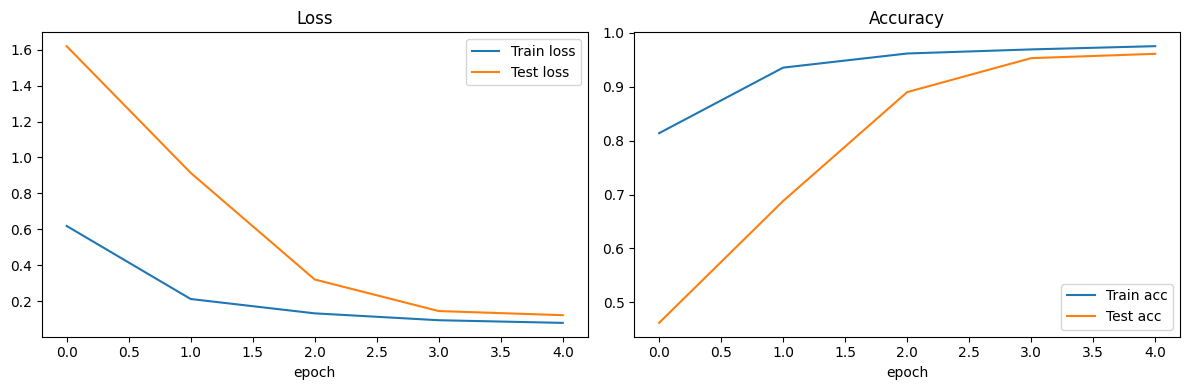

In [13]:
#VISUALIZATION
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['loss'],label='Train loss')
axes[0].plot(history.history['val_loss'],label='Test loss')
axes[0].set_xlabel('epoch')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],label='Train acc')
axes[1].plot(history.history['val_accuracy'],label='Test acc')
axes[1].set_xlabel('epoch')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
#PREDICTION+EVALUATION
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

y_pred = np.argmax(model.predict(X_test),axis=1)
print("Acc:",accuracy_score(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classi report:\n",classification_report(y_test,y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Acc: 0.961
confusion matrix:
 [[ 84   0   0   0   0   1   0   0   0   0]
 [  0 123   0   1   0   1   0   0   1   0]
 [  2   1 108   2   0   0   0   2   0   1]
 [  0   0   0 102   0   5   0   0   0   0]
 [  0   0   1   0 107   0   0   0   0   2]
 [  0   0   0   0   0  86   1   0   0   0]
 [  4   0   0   0   0   0  83   0   0   0]
 [  0   0   0   1   1   0   0  94   0   3]
 [  2   0   0   2   1   0   2   1  80   1]
 [  0   0   0   0   0   0   0   0   0  94]]
classi report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95        85
           1       0.99      0.98      0.98       126
           2       0.99      0.93      0.96       116
           3       0.94      0.95      0.95       107
           4       0.98      0.97      0.98       110
           5       0.92      0.99      0.96        87
           6       0.97      0.95      0.96        87
           7       0.97      0.95      0.96        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted class: 7
Actual class: 7


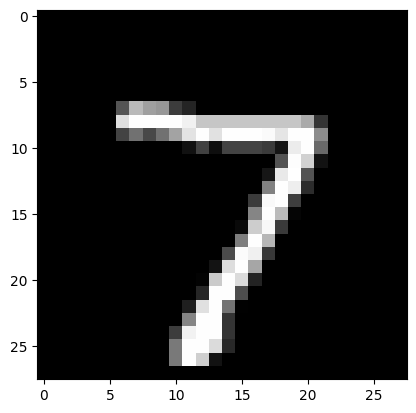

In [21]:
#PREDICT 1 INSTANCE - Reshape first
sample = X_test[0].reshape(1,28,28,1)
predicted = model.predict(sample)

plt.imshow(X_test[0],cmap="gray")

print("Predicted class:",np.argmax(predicted))
print("Actual class:",y_test[0])

